# 서울 지하철 퇴근시간 이용객 예측

서울교통공사의 **2025년 일별·역별·시간대별 승하차 데이터**로 같은 선형 회귀 모델을 학습하고, `Adam + L2`와 `AdamW`의 차이를 비교합니다.

> **예측 목표:** 당일 17시 이전의 승하차 패턴으로 각 역의 **17~21시 이용객 수**를 예측

## 1. 발표 질문

1. 2025년에 가장 많이 이용한 서울 지하철역은 어디인가?
2. 역별 이용객은 시간대에 따라 어떻게 달라지는가?
3. 오전부터 16시까지의 승하차 인원으로 17~21시 이용객을 예측할 수 있는가?
4. 같은 모델을 학습했을 때 Adam + L2와 AdamW 중 어느 optimizer가 더 정확한가?

### 데이터 규모

- 기간: 2025년 1월 1일~12월 31일
- 관측 단위: 날짜 × 호선 × 역
- 표본: **99,645개**
- 역·호선 조합: **273개**
- 출처: [서울교통공사 역별 일별 시간대별 승하차인원](https://data.seoul.go.kr/dataList/OA-12921/F/1/datasetView.do)

In [1]:
from dataclasses import dataclass
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

DATA_PATH = Path("data/seoul_subway_daily_2025.csv.gz")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

FONT_FAMILY = ["Apple SD Gothic Neo", "AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
LINE_COLORS = {
    "1호선": "#0052A4", "2호선": "#00A84D", "3호선": "#EF7C1C", "4호선": "#00A5DE",
    "5호선": "#996CAC", "6호선": "#CD7C2F", "7호선": "#747F00", "8호선": "#E6186C",
}

TOKENS = {
    "surface": "#FCFCFD", "panel": "#FFFFFF", "ink": "#1F2430",
    "muted": "#6F768A", "grid": "#E6E8F0", "axis": "#D7DBE7",
    "blue": "#5477C4", "blue_light": "#CEDFFE",
    "orange": "#CC6F47", "orange_light": "#FFBDA1",
    "gold": "#FFE15B", "olive": "#71B436",
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": FONT_FAMILY,
    "axes.unicode_minus": False, "figure.facecolor": TOKENS["surface"],
    "axes.facecolor": TOKENS["panel"], "axes.edgecolor": TOKENS["axis"],
    "axes.labelcolor": TOKENS["ink"], "text.color": TOKENS["ink"],
    "xtick.color": TOKENS["muted"], "ytick.color": TOKENS["muted"],
    "grid.color": TOKENS["grid"], "grid.linewidth": 0.8,
})


def add_header(fig, ax, title, subtitle, top=0.94):
    ax.set_title("")
    fig.subplots_adjust(top=0.80)
    left = ax.get_position().x0
    fig.text(left, top, title, fontsize=17, fontweight="bold", ha="left", va="top")
    fig.text(left, top - 0.052, textwrap.fill(subtitle, 108), fontsize=10.5,
             color=TOKENS["muted"], ha="left", va="top")


def finish_axes(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, color=TOKENS["grid"], linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(TOKENS["axis"])
    ax.spines["bottom"].set_color(TOKENS["axis"])


def save_figure(fig, name):
    for extension in ("png", "svg"):
        fig.savefig(OUTPUT_DIR / f"{name}.{extension}", dpi=220,
                    bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

assert DATA_PATH.exists(), f"데이터 파일이 없습니다: {DATA_PATH.resolve()}"

## 2. 데이터 확인

원본의 승차·하차 행을 날짜·호선·역 단위로 합친 데이터입니다.

In [2]:
subway = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
subway["date"] = pd.to_datetime(subway["date"])
subway["역_호선"] = subway["역명"] + " · " + subway["호선"]

TIME_COLUMNS = ["06시이전"] + [f"{hour:02d}-{hour+1:02d}시간대" for hour in range(6, 24)] + ["24시이후"]
EARLY_COLUMNS = ["06시이전"] + [f"{hour:02d}-{hour+1:02d}시간대" for hour in range(6, 17)]
EVENING_COLUMNS = ["17-18시간대", "18-19시간대", "19-20시간대", "20-21시간대"]

print(f"기간: {subway['date'].min().date()} ~ {subway['date'].max().date()}")
print(f"표본 수: {len(subway):,}개")
print(f"역·호선 조합: {subway[['호선', '역번호']].drop_duplicates().shape[0]:,}개")
display(subway[["date", "호선", "역명", "합계_승차", "합계_하차", "총이용객"]].head())

assert len(subway) == 99645
assert subway[["호선", "역번호"]].drop_duplicates().shape[0] == 273
assert subway[TIME_COLUMNS].notna().all().all()

기간: 2025-01-01 ~ 2025-12-31
표본 수: 99,645개
역·호선 조합: 273개


,date,호선,역명,합계_승차,합계_하차,총이용객
0,2025-01-01,1호선,서울역,42041,35687,77728
1,2025-01-01,1호선,시청,11939,11466,23405
2,2025-01-01,1호선,종각,15517,13044,28561
3,2025-01-01,1호선,종로3가,13946,11765,25711
4,2025-01-01,1호선,종로5가,10849,10578,21427


## 3. 2025년 가장 많이 이용한 역

승차와 하차를 합산한 연간 이용객 순위입니다. 막대의 색은 각 역에 포함된 **1~8호선 이용객 구성**을 나타냅니다.

예를 들어 잠실 막대의 초록색은 2호선, 분홍색은 8호선 이용객입니다. 환승 인원을 별도로 센 값이 아니라 호선별 승하차 인원을 합산한 결과입니다.

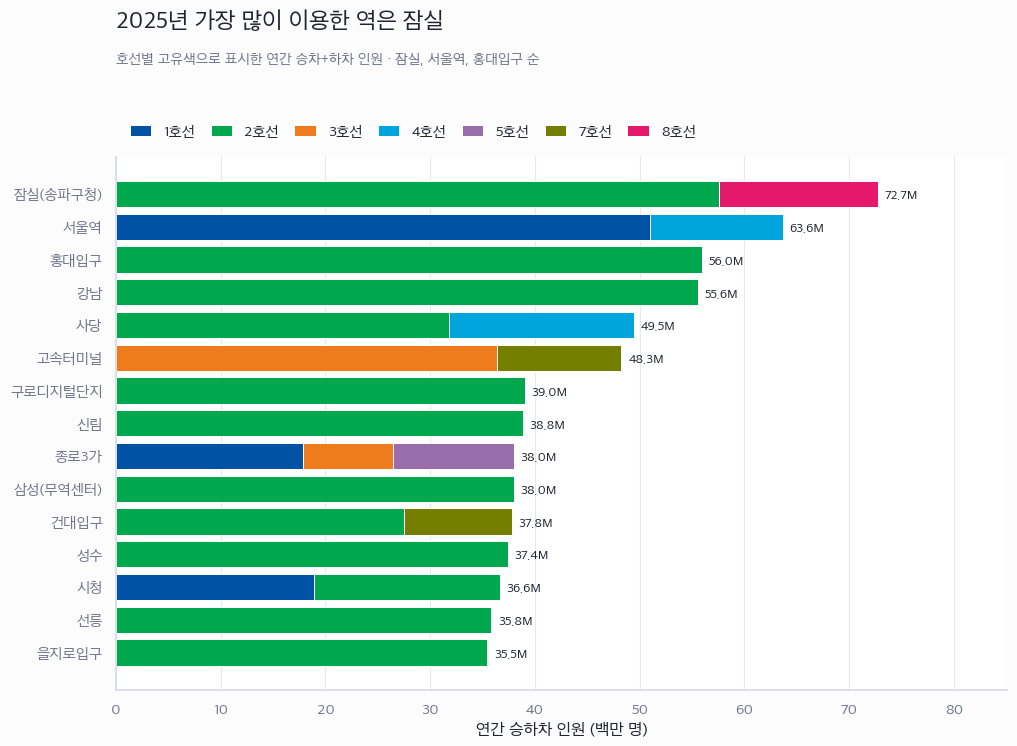

In [3]:
station_line = subway.groupby(["역명", "호선"], as_index=False)["총이용객"].sum()
station_total = (station_line.groupby("역명", as_index=False)["총이용객"].sum()
                 .sort_values("총이용객", ascending=False))
top_station_names = station_total.head(15)["역명"].tolist()
ranking_matrix = (station_line.loc[station_line["역명"].isin(top_station_names)]
                  .pivot(index="역명", columns="호선", values="총이용객")
                  .fillna(0)
                  .reindex(top_station_names[::-1])) / 1_000_000

fig, ax = plt.subplots(figsize=(11.5, 8.2))
left = np.zeros(len(ranking_matrix))
for line in LINE_COLORS:
    if line not in ranking_matrix.columns:
        continue
    values = ranking_matrix[line].to_numpy()
    ax.barh(ranking_matrix.index, values, left=left, color=LINE_COLORS[line],
            edgecolor="white", linewidth=0.7, label=line)
    left += values

for y_position, total in enumerate(left):
    ax.text(total + 0.65, y_position, f"{total:.1f}M", va="center",
            fontsize=9.5, fontweight="bold", color=TOKENS["ink"])
ax.set_xlabel("연간 승하차 인원 (백만 명)")
ax.set_ylabel("")
ax.set_xlim(0, left.max() * 1.17)
ax.legend(frameon=False, ncol=8, loc="lower left", bbox_to_anchor=(0, 1.01),
          columnspacing=1.0, handlelength=1.4)
add_header(fig, ax, "2025년 가장 많이 이용한 역은 잠실", "호선별 고유색으로 표시한 연간 승차+하차 인원 · 잠실, 서울역, 홍대입구 순")
fig.subplots_adjust(top=0.76)
finish_axes(ax, grid_axis="x")
save_figure(fig, "01_busiest_subway_stations")

## 4. 상위 역의 시간대별 이용 패턴

상위 역·호선 조합의 하루 평균 승하차 인원을 시간대별로 비교합니다. 왼쪽 역 이름 색도 해당 호선의 고유색과 맞췄습니다.

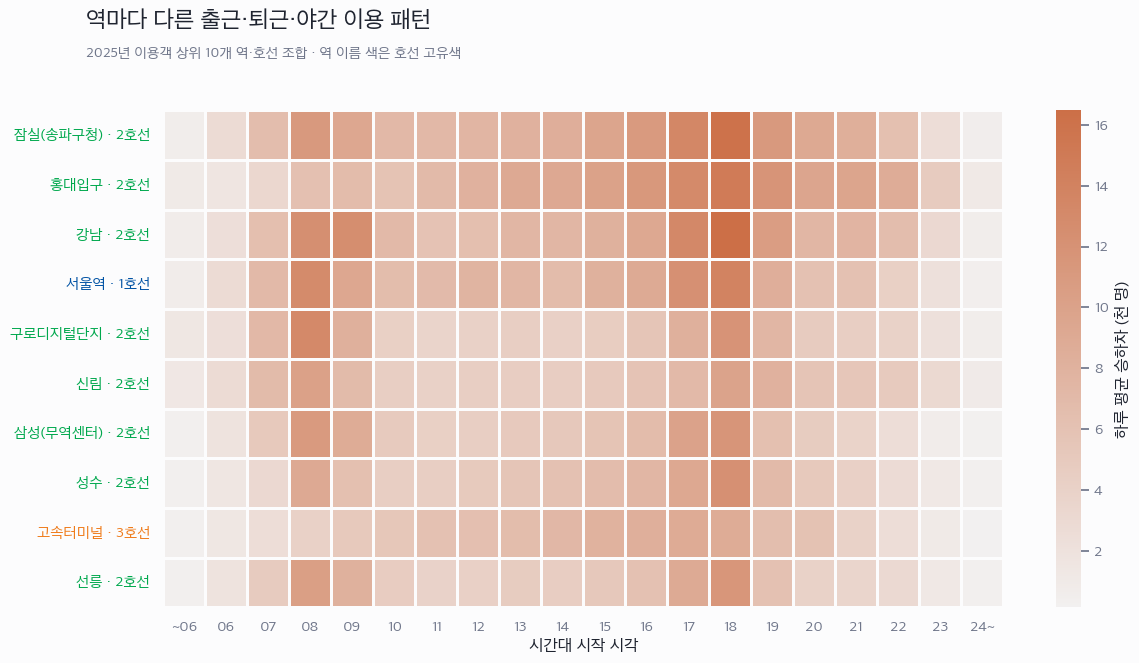

In [4]:
station_line_total = (subway.groupby(["역명", "호선"], as_index=False)["총이용객"].sum()
                      .nlargest(10, "총이용객"))
top_station_lines = station_line_total[["역명", "호선"]].copy()
top_station_lines["역_호선"] = top_station_lines["역명"] + " · " + top_station_lines["호선"]

hourly_by_station_date = subway.groupby(["date", "역명", "호선"], as_index=False)[TIME_COLUMNS].sum()
hourly_subset = hourly_by_station_date.merge(top_station_lines[["역명", "호선", "역_호선"]], on=["역명", "호선"])
hourly_profile = (hourly_subset.groupby("역_호선")[TIME_COLUMNS].mean()
                  .reindex(top_station_lines["역_호선"]) / 1000)
hour_labels = ["~06"] + [f"{hour:02d}" for hour in range(6, 24)] + ["24~"]
hourly_profile.columns = hour_labels

fig, ax = plt.subplots(figsize=(14, 7.2))
sns.heatmap(hourly_profile, cmap=sns.light_palette(TOKENS["orange"], as_cmap=True),
            linewidths=1.0, linecolor=TOKENS["surface"],
            cbar_kws={"label": "하루 평균 승하차 (천 명)"}, ax=ax)
for tick_label in ax.get_yticklabels():
    line = tick_label.get_text().split(" · ")[-1]
    tick_label.set_color(LINE_COLORS.get(line, TOKENS["muted"]))
    tick_label.set_fontweight("bold")
ax.set_xlabel("시간대 시작 시각")
ax.set_ylabel("")
add_header(fig, ax, "역마다 다른 출근·퇴근·야간 이용 패턴", "2025년 이용객 상위 10개 역·호선 조합 · 역 이름 색은 호선 고유색")
fig.subplots_adjust(top=0.80, left=0.18, right=0.93)
save_figure(fig, "02_station_hourly_heatmap")

## 5. 무엇을 예측하는가?

### 모델에 넣는 정보

- 같은 날 06시 이전부터 16~17시까지의 시간대별 승하차 인원
- 요일
- 호선

### 모델이 예측하는 값

- 같은 날 **17~21시 승하차 인원 합계**

이 값을 실제로 측정된 17~21시 승하차 인원과 비교해 오차를 계산합니다.

### 기간 분리

| 구분 | 기간 | 용도 |
|---|---|---|
| 학습 | 1~10월 | 모델 학습 |
| 검증 | 11월 | 학습 과정 확인 |
| 평가 | **12월** | 실제 측정값과 최종 비교 |

두 optimizer는 같은 선형 회귀 모델, 데이터, 초기 가중치와 학습률을 사용합니다.

In [5]:
model_data = subway.copy()
model_data["퇴근시간_이용객"] = model_data[EVENING_COLUMNS].sum(axis=1)
model_data["요일"] = model_data["date"].dt.dayofweek

numeric_features = np.log1p(model_data[EARLY_COLUMNS]).reset_index(drop=True)
day_features = pd.get_dummies(model_data["요일"], prefix="요일", dtype=float).reset_index(drop=True)
line_features = pd.get_dummies(model_data["호선"], prefix="호선", dtype=float).reset_index(drop=True)
feature_frame = pd.concat([numeric_features, day_features, line_features], axis=1)

train_mask = model_data["date"].lt("2025-11-01").to_numpy()
validation_mask = model_data["date"].between("2025-11-01", "2025-11-30").to_numpy()
test_mask = model_data["date"].ge("2025-12-01").to_numpy()

feature_mean = feature_frame.loc[train_mask].mean()
feature_std = feature_frame.loc[train_mask].std().replace(0, 1)
X = ((feature_frame - feature_mean) / feature_std).to_numpy(dtype=float)
X = np.column_stack([X, np.ones(len(X))])  # bias

y_log = np.log1p(model_data["퇴근시간_이용객"].to_numpy(dtype=float))
target_mean = y_log[train_mask].mean()
target_std = y_log[train_mask].std()
y = (y_log - target_mean) / target_std

print(f"학습 표본: {train_mask.sum():,}개")
print(f"검증 표본: {validation_mask.sum():,}개")
print(f"12월 평가 표본: {test_mask.sum():,}개")
print(f"입력 변수: {X.shape[1] - 1:,}개 + bias")

학습 표본: 82,992개
검증 표본: 8,190개
12월 평가 표본: 8,463개
입력 변수: 27개 + bias


## 6. 같은 모델, 다른 optimizer

| 구분 | Adam + L2 | AdamW |
|---|---|---|
| `m`, `v` 계산 | 데이터 gradient + `λw` | 데이터 gradient만 사용 |
| Weight decay | Adam의 적응형 스케일링에 포함 | 파라미터 업데이트에서 직접 적용 |
| 영향 | 정규화 항이 모멘트의 방향·크기에 개입 | 데이터 학습과 가중치 감소를 분리 |

```python
# Adam + L2
gradient_for_moments = data_gradient + weight_decay * weights

# AdamW
gradient_for_moments = data_gradient
weights -= adam_update + learning_rate * weight_decay * weights
```

In [6]:
@dataclass
class OptimizerRun:
    name: str
    weights: np.ndarray
    predictions: np.ndarray
    validation_rmse: np.ndarray
    weight_norm: np.ndarray
    test_rmse: float
    test_mae: float


def to_passengers(normalized_prediction):
    return np.expm1(normalized_prediction * target_std + target_mean)


def run_optimizer(method, epochs=150, learning_rate=0.02, weight_decay=0.10,
                  beta1=0.9, beta2=0.999, epsilon=1e-8, batch_size=4096):
    weights = np.zeros(X.shape[1])
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    decay_mask = np.ones_like(weights)
    decay_mask[-1] = 0.0
    train_indexes = np.flatnonzero(train_mask)
    random = np.random.default_rng(42)
    step = 0
    validation_history, norm_history = [], []

    for _ in range(epochs):
        shuffled = random.permutation(train_indexes)
        for start in range(0, len(shuffled), batch_size):
            indexes = shuffled[start:start + batch_size]
            step += 1
            prediction = X[indexes] @ weights
            data_gradient = 2 * X[indexes].T @ (prediction - y[indexes]) / len(indexes)

            if method == "adam_l2":
                gradient_for_moments = data_gradient + weight_decay * weights * decay_mask
            elif method == "adamw":
                gradient_for_moments = data_gradient
            else:
                raise ValueError("method must be 'adam_l2' or 'adamw'")

            first_moment = beta1 * first_moment + (1 - beta1) * gradient_for_moments
            second_moment = beta2 * second_moment + (1 - beta2) * gradient_for_moments**2
            corrected_m = first_moment / (1 - beta1**step)
            corrected_v = second_moment / (1 - beta2**step)
            weights -= learning_rate * corrected_m / (np.sqrt(corrected_v) + epsilon)

            if method == "adamw":
                weights -= learning_rate * weight_decay * weights * decay_mask

        validation_prediction = to_passengers(X[validation_mask] @ weights)
        validation_actual = model_data.loc[validation_mask, "퇴근시간_이용객"].to_numpy()
        validation_history.append(np.sqrt(np.mean((validation_prediction - validation_actual)**2)))
        norm_history.append(np.linalg.norm(weights[:-1]))

    test_prediction = to_passengers(X[test_mask] @ weights)
    test_actual = model_data.loc[test_mask, "퇴근시간_이용객"].to_numpy()
    label = "Adam + L2" if method == "adam_l2" else "AdamW"
    return OptimizerRun(
        label, weights, test_prediction, np.array(validation_history), np.array(norm_history),
        float(np.sqrt(np.mean((test_prediction - test_actual)**2))),
        float(np.mean(np.abs(test_prediction - test_actual))),
    )


adam_l2 = run_optimizer("adam_l2")
adamw = run_optimizer("adamw")

result_table = pd.DataFrame({
    "optimizer": [adam_l2.name, adamw.name],
    "12월 RMSE": [adam_l2.test_rmse, adamw.test_rmse],
    "12월 MAE": [adam_l2.test_mae, adamw.test_mae],
    "가중치 L2 norm": [np.linalg.norm(adam_l2.weights[:-1]), np.linalg.norm(adamw.weights[:-1])],
})
display(result_table.style.format({"12월 RMSE": "{:,.0f}명", "12월 MAE": "{:,.0f}명", "가중치 L2 norm": "{:.3f}"}))

rmse_improvement = (adam_l2.test_rmse - adamw.test_rmse) / adam_l2.test_rmse * 100
mae_improvement = (adam_l2.test_mae - adamw.test_mae) / adam_l2.test_mae * 100
print(f"AdamW RMSE 개선: {rmse_improvement:.1f}%")
print(f"AdamW MAE 개선: {mae_improvement:.1f}%")

assert adamw.test_rmse < adam_l2.test_rmse
assert adamw.test_mae < adam_l2.test_mae
assert not np.allclose(adam_l2.weights, adamw.weights)

,optimizer,12월 RMSE,12월 MAE,가중치 L2 norm
0,Adam + L2,"1,927명","1,087명",0.444
1,AdamW,"1,774명",995명,0.811


AdamW RMSE 개선: 8.0%
AdamW MAE 개선: 8.5%


## 7. 결과: AdamW가 더 정확했다

12월의 8,463개 역·날짜 표본에서 실제 17~21시 이용객과 예측값을 비교합니다.

- **Adam + L2:** RMSE 약 1,927명
- **AdamW:** RMSE 약 1,774명
- AdamW의 RMSE가 약 **8% 낮음**

같은 모델과 학습률에서도 weight decay 적용 방식 때문에 학습 경로와 최종 예측이 달라졌습니다.

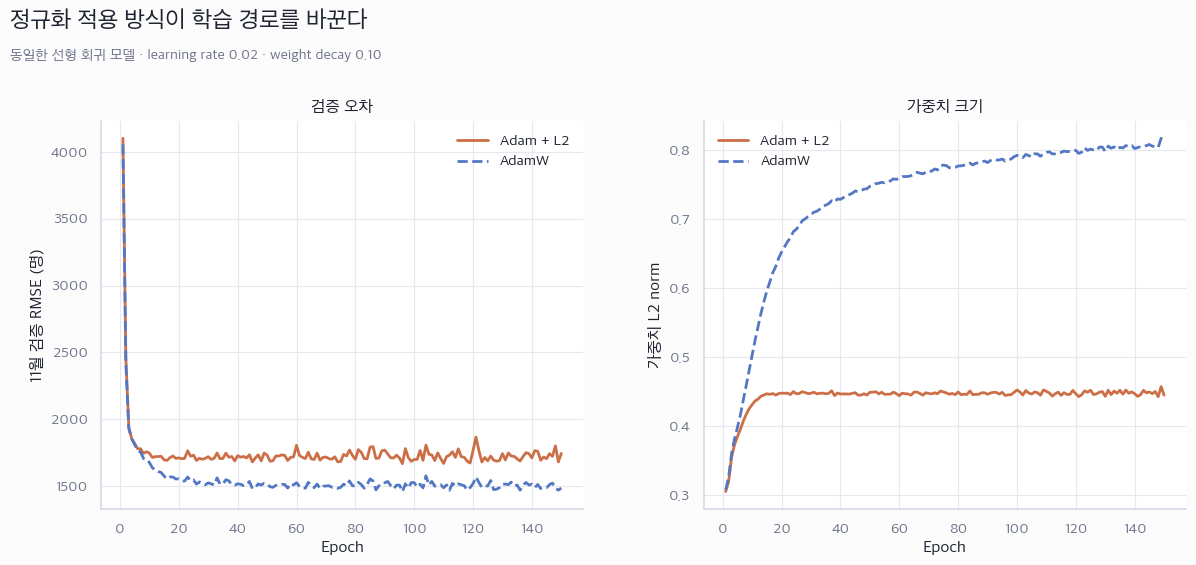

In [7]:
epochs = np.arange(1, len(adam_l2.validation_rmse) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
fig.subplots_adjust(top=0.78, wspace=0.25)

ax = axes[0]
ax.plot(epochs, adam_l2.validation_rmse, color=TOKENS["orange"], label="Adam + L2", linewidth=2)
ax.plot(epochs, adamw.validation_rmse, color=TOKENS["blue"], label="AdamW", linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("11월 검증 RMSE (명)")
ax.set_title("검증 오차")
ax.legend(frameon=False)
finish_axes(ax, grid_axis="both")

ax = axes[1]
ax.plot(epochs, adam_l2.weight_norm, color=TOKENS["orange"], label="Adam + L2", linewidth=2)
ax.plot(epochs, adamw.weight_norm, color=TOKENS["blue"], label="AdamW", linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("가중치 L2 norm")
ax.set_title("가중치 크기")
ax.legend(frameon=False)
finish_axes(ax, grid_axis="both")

fig.text(0.06, 0.94, "정규화 적용 방식이 학습 경로를 바꾼다", fontsize=17, fontweight="bold", ha="left")
fig.text(0.06, 0.885, "동일한 선형 회귀 모델 · learning rate 0.02 · weight decay 0.10",
         fontsize=10.5, color=TOKENS["muted"], ha="left")
save_figure(fig, "03_optimizer_training")

### 실제 측정값과 예측값을 역별로 비교

12월 퇴근시간 이용객이 많은 역·호선 12곳의 하루 평균을 비교합니다.

- 검은 막대: 실제로 측정된 평균 이용객
- 주황 막대: Adam + L2 예측
- 파란 막대: AdamW 예측

예측 막대가 검은 막대와 가까울수록 정확합니다.

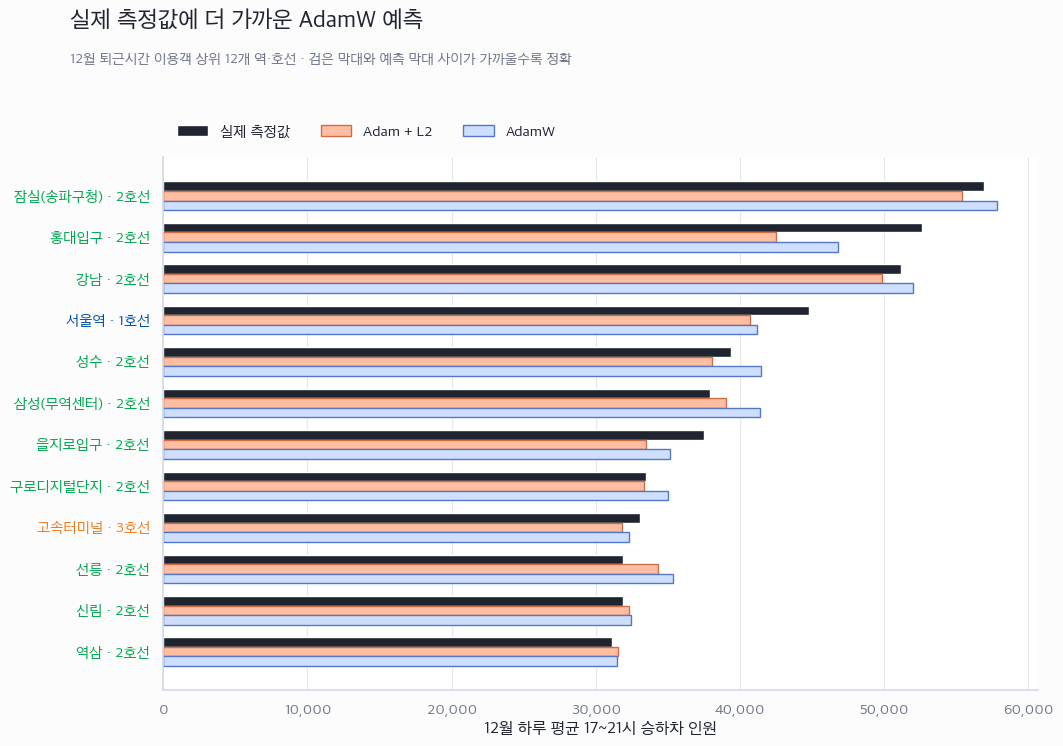

In [8]:
test_results = model_data.loc[test_mask, ["date", "호선", "역명", "퇴근시간_이용객"]].copy()
test_results["Adam + L2"] = adam_l2.predictions
test_results["AdamW"] = adamw.predictions

station_comparison = (test_results.groupby(["역명", "호선"], as_index=False)
                      .agg(실제값=("퇴근시간_이용객", "mean"),
                           Adam_L2=("Adam + L2", "mean"),
                           AdamW=("AdamW", "mean"))
                      .nlargest(12, "실제값")
                      .sort_values("실제값"))
station_comparison["역_호선"] = station_comparison["역명"] + " · " + station_comparison["호선"]

fig, ax = plt.subplots(figsize=(12.5, 8.2))
y_positions = np.arange(len(station_comparison))
bar_height = 0.23
ax.barh(y_positions + bar_height, station_comparison["실제값"], height=bar_height,
        color=TOKENS["ink"], label="실제 측정값")
ax.barh(y_positions, station_comparison["Adam_L2"], height=bar_height,
        color=TOKENS["orange_light"], edgecolor=TOKENS["orange"], label="Adam + L2")
ax.barh(y_positions - bar_height, station_comparison["AdamW"], height=bar_height,
        color=TOKENS["blue_light"], edgecolor=TOKENS["blue"], label="AdamW")

ax.set_yticks(y_positions, station_comparison["역_호선"])
for tick_label, line in zip(ax.get_yticklabels(), station_comparison["호선"]):
    tick_label.set_color(LINE_COLORS.get(line, TOKENS["muted"]))
    tick_label.set_fontweight("bold")
ax.set_xlabel("12월 하루 평균 17~21시 승하차 인원")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=False, ncol=3, loc="lower left", bbox_to_anchor=(0, 1.01))
add_header(fig, ax, "실제 측정값에 더 가까운 AdamW 예측", "12월 퇴근시간 이용객 상위 12개 역·호선 · 검은 막대와 예측 막대 사이가 가까울수록 정확")
fig.subplots_adjust(top=0.76, left=0.20)
finish_axes(ax, grid_axis="x")
save_figure(fig, "04_actual_vs_predicted")

### 강남역 2호선의 12월 예측

실제 시계열에서 두 optimizer의 차이를 확인합니다.

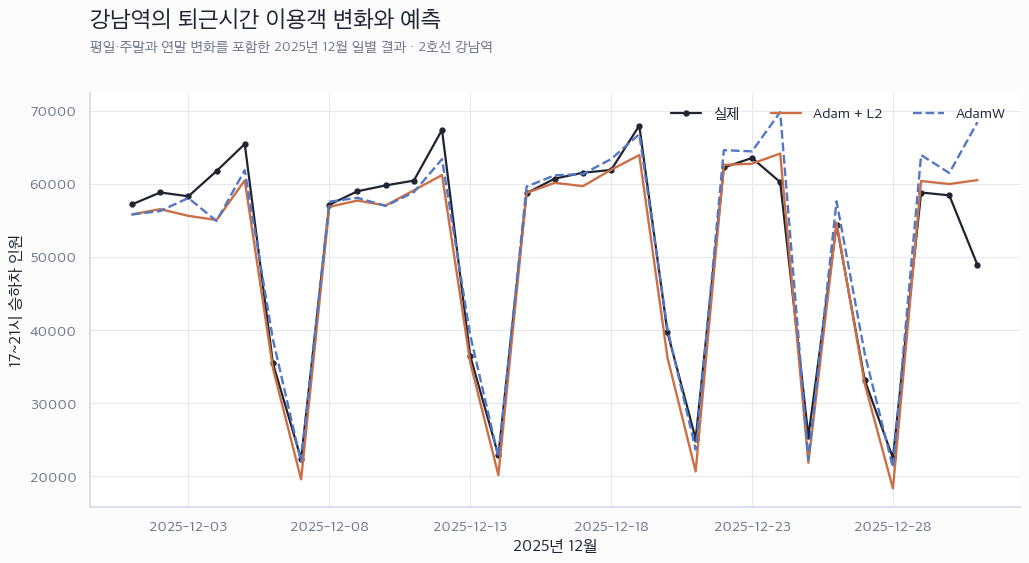

In [9]:
test_results = model_data.loc[test_mask, ["date", "호선", "역명", "퇴근시간_이용객"]].copy()
test_results["Adam + L2"] = adam_l2.predictions
test_results["AdamW"] = adamw.predictions
station_series = test_results.loc[(test_results["역명"] == "강남") & (test_results["호선"] == "2호선")]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(station_series["date"], station_series["퇴근시간_이용객"], color=TOKENS["ink"],
        marker="o", markersize=3.5, linewidth=1.6, label="실제")
ax.plot(station_series["date"], station_series["Adam + L2"], color=TOKENS["orange"],
        linewidth=1.7, label="Adam + L2")
ax.plot(station_series["date"], station_series["AdamW"], color=TOKENS["blue"],
        linewidth=1.7, linestyle="--", label="AdamW")
ax.set_xlabel("2025년 12월")
ax.set_ylabel("17~21시 승하차 인원")
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
add_header(fig, ax, "강남역의 퇴근시간 이용객 변화와 예측", "평일·주말과 연말 변화를 포함한 2025년 12월 일별 결과 · 2호선 강남역")
finish_axes(ax, grid_axis="both")
save_figure(fig, "05_gangnam_december_forecast")

## 8. 왜 결과가 다른가?

데이터 gradient가 0인 첫 스텝을 보면 차이가 분명합니다.

- Adam + L2: $w_1 \approx w_0 - \alpha\,\mathrm{sign}(w_0)$
- AdamW: $w_1 = (1 - \alpha\lambda)w_0$

**Adam + L2**는 `λw`가 데이터 gradient와 함께 `m`, `v`에 들어갑니다. 따라서 정규화 항도 Adam의 좌표별 적응형 스케일링을 받습니다.

**AdamW**는 `m`, `v`를 데이터 gradient만으로 계산하고, weight decay를 파라미터에 직접 적용합니다. 이 분리 때문에 같은 `λ`를 사용해도 학습 경로와 최종 가중치가 달라집니다.

## 9. 결론

> **당일 17시 이전의 역별 승하차 패턴으로 17~21시 이용객을 예측한 결과, AdamW가 Adam + L2보다 정확했습니다.**

| 항목 | 결과 |
|---|---|
| 데이터 | 2025년 99,645개 날짜·역·호선 표본 |
| 가장 많이 이용한 역 | 잠실(송파구청), 연간 약 7,272만 명 |
| 최종 평가 | 2025년 12월 8,463개 표본 |
| Adam + L2 RMSE | 약 1,927명 |
| **AdamW RMSE** | **약 1,774명** |
| RMSE 감소 | **약 8%** |

Adam + L2는 정규화 항을 모멘트 계산에 섞지만, AdamW는 데이터 gradient와 weight decay를 분리합니다. 이번 지하철 데이터에서는 AdamW가 퇴근시간 이용객 변화를 더 정확하게 예측했습니다.